In [2]:
%pip install pandas numpy matplotlib seaborn plotly scikit-learn scipy missingno openai streamlit ydata-profiling sweetviz

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

import missingno as msno

import sweetviz as sv

import warnings
warnings.filterwarnings("ignore")

In [120]:
df = pd.read_csv("tech_layoffs_til_2025.csv")

In [121]:
df.head()

,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude
0,1,Tamara Mellon,Los Angeles,other,California,USA,North America,20.0,2020-03-12,40.0,50.0,30.0,Retail,Series C,90.0,2020,34.053691,-118.242766
1,2,HopSkipDrive,Los Angeles,other,California,USA,North America,8.0,2020-03-13,10.0,80.0,72.0,Transportation,Unknown,45.0,2020,34.053691,-118.242766
2,3,Panda Squad,San Francisco,San Francisco Bay Area,California,USA,North America,6.0,2020-03-13,75.0,8.0,2.0,Consumer,Seed,1.0,2020,37.779259,-122.419329
3,4,Help.com,Austin,other,Texas,USA,North America,16.0,2020-03-16,100.0,16.0,0.0,Support,Seed,6.0,2020,30.271129,-97.743700
4,5,Inspirato,Denver,other,Colorado,USA,North America,130.0,2020-03-16,22.0,591.0,461.0,Travel,Series C,79.0,2020,39.739236,-104.984862


In [122]:
df.shape


(2412, 18)

In [123]:
df.columns

Index(['Nr', 'Company', 'Location_HQ', 'Region', 'USState', 'Country',
       'Continent', 'Laid_Off', 'Date_layoffs', 'Percentage',
       'Company_Size_before_Layoffs', 'Company_Size_after_layoffs', 'Industry',
       'Stage', 'Money_Raised_in__mil', 'Year', 'latitude', 'longitude'],
      dtype='object')

In [126]:
list(df.columns)

['Nr',
 'Company',
 'Location_HQ',
 'Region',
 'USState',
 'Country',
 'Continent',
 'Laid_Off',
 'Date_layoffs',
 'Percentage',
 'Company_Size_before_Layoffs',
 'Company_Size_after_layoffs',
 'Industry',
 'Stage',
 'Money_Raised_in__mil',
 'Year',
 'latitude',
 'longitude']

In [127]:
df.describe()

,Nr,Laid_Off,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Money_Raised_in__mil,Year,latitude,longitude
count,2412.000000,2040.000000,1963.000000,1769.000000,1857.000000,2048.000000,2412.000000,2412.000000,2412.000000
mean,1206.500000,366.082843,26.157005,4490.323347,3962.725902,683.777832,2022.905473,35.024630,-58.672372
std,696.428747,1406.974368,27.417253,26452.737715,25047.520842,4292.579693,1.523281,16.757666,74.273277
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2020.000000,-41.288795,-123.262044
25%,603.750000,40.000000,9.600000,215.000000,121.000000,50.000000,2022.000000,34.053691,-122.159847
50%,1206.500000,95.000000,16.000000,571.000000,402.000000,161.000000,2023.000000,37.779259,-79.383935
75%,1809.250000,200.000000,30.000000,1538.000000,1221.000000,451.250000,2024.000000,42.355433,-0.144055
max,2412.000000,30000.000000,100.000000,600000.000000,588000.000000,121900.000000,2025.000000,60.204767,174.777211


In [128]:
df.describe(include='all')

,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude
count,2412.000000,2412,2412,2412,2411,2412,2412,2040.000000,2412,1963.000000,1769.000000,1857.000000,2412,2248,2048.000000,2412.000000,2412.000000,2412.000000
unique,NaN,1713,243,5,76,49,6,NaN,935,NaN,NaN,NaN,118,16,NaN,NaN,NaN,NaN
top,NaN,Google,San Francisco,other,California,USA,North America,NaN,2020-04-02,NaN,NaN,NaN,Finance,Post-IPO,NaN,NaN,NaN,NaN
freq,NaN,16,369,1628,747,1557,1667,NaN,16,NaN,NaN,NaN,289,574,NaN,NaN,NaN,NaN
mean,1206.500000,NaN,NaN,NaN,NaN,NaN,NaN,366.082843,NaN,26.157005,4490.323347,3962.725902,NaN,NaN,683.777832,2022.905473,35.024630,-58.672372
std,696.428747,NaN,NaN,NaN,NaN,NaN,NaN,1406.974368,NaN,27.417253,26452.737715,25047.520842,NaN,NaN,4292.579693,1.523281,16.757666,74.273277
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,2020.000000,-41.288795,-123.262044
25%,603.750000,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,NaN,9.600000,215.000000,121.000000,NaN,NaN,50.000000,2022.000000,34.053691,-122.159847
50%,1206.500000,NaN,NaN,NaN,NaN,NaN,NaN,95.000000,NaN,16.000000,571.000000,402.000000,NaN,NaN,161.000000,2023.000000,37.779259,-79.383935
75%,1809.250000,NaN,NaN,NaN,NaN,NaN,NaN,200.000000,NaN,30.000000,1538.000000,1221.000000,NaN,NaN,451.250000,2024.000000,42.355433,-0.144055


In [129]:
df.memory_usage(deep=True).sum()

np.int64(1419049)

In [130]:
print(f"Memory Usage: {df.memory_usage(deep=True).sum()/1024**2:.2f} MB")

Memory Usage: 1.35 MB


In [131]:
df.duplicated().sum()

np.int64(0)

In [132]:
df[df.duplicated()]

,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Nr                           2412 non-null   int64  
 1   Company                      2412 non-null   object 
 2   Location_HQ                  2412 non-null   object 
 3   Region                       2412 non-null   object 
 4   USState                      2411 non-null   object 
 5   Country                      2412 non-null   object 
 6   Continent                    2412 non-null   object 
 7   Laid_Off                     2040 non-null   float64
 8   Date_layoffs                 2412 non-null   object 
 9   Percentage                   1963 non-null   float64
 10  Company_Size_before_Layoffs  1769 non-null   float64
 11  Company_Size_after_layoffs   1857 non-null   float64
 12  Industry                     2412 non-null   object 
 13  Stage             

In [134]:
# Missing values count
missing_values = df.isnull().sum()

# Missing values percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Summary table
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

missing_df = missing_df[missing_df['Missing Values'] > 0]
missing_df = missing_df.sort_values(by='Percentage (%)', ascending=False)

missing_df

,Missing Values,Percentage (%)
Company_Size_before_Layoffs,643,26.658375
Company_Size_after_layoffs,555,23.009950
Percentage,449,18.615257
Laid_Off,372,15.422886
Money_Raised_in__mil,364,15.091211
Stage,164,6.799337
USState,1,0.041459


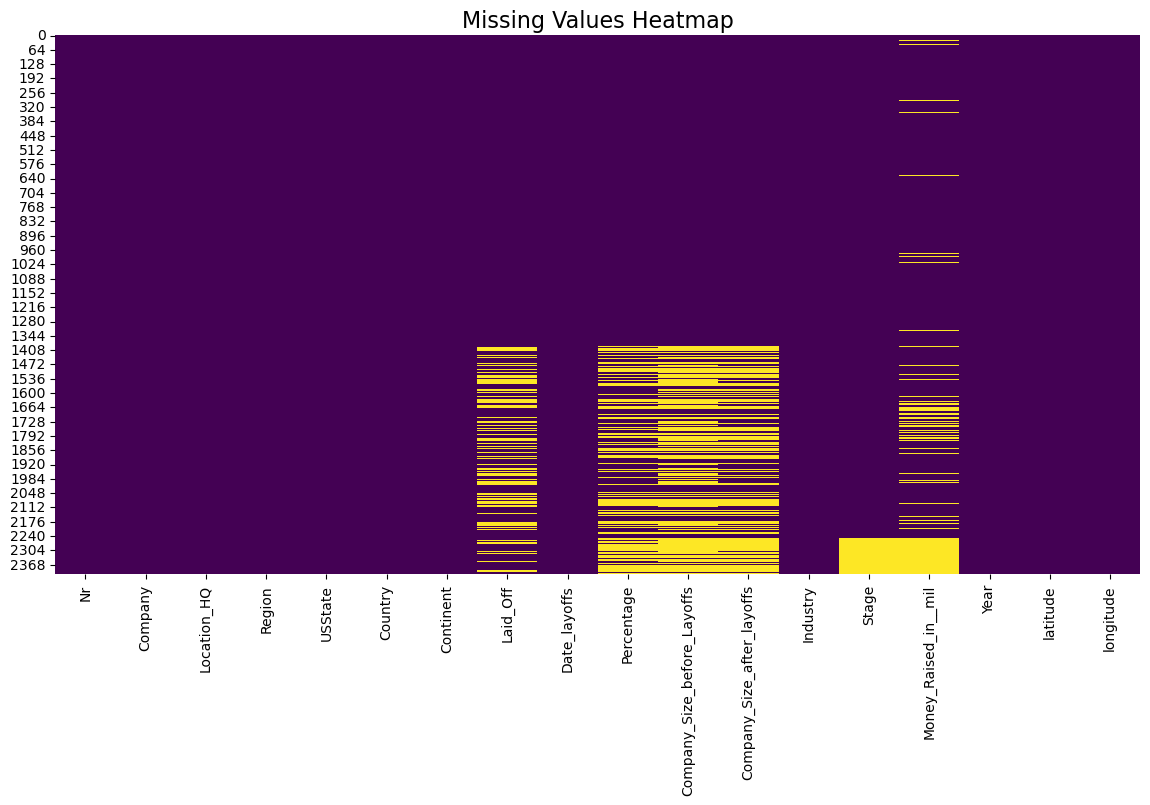

In [135]:
plt.figure(figsize=(14,7))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap", fontsize=16)
plt.show()

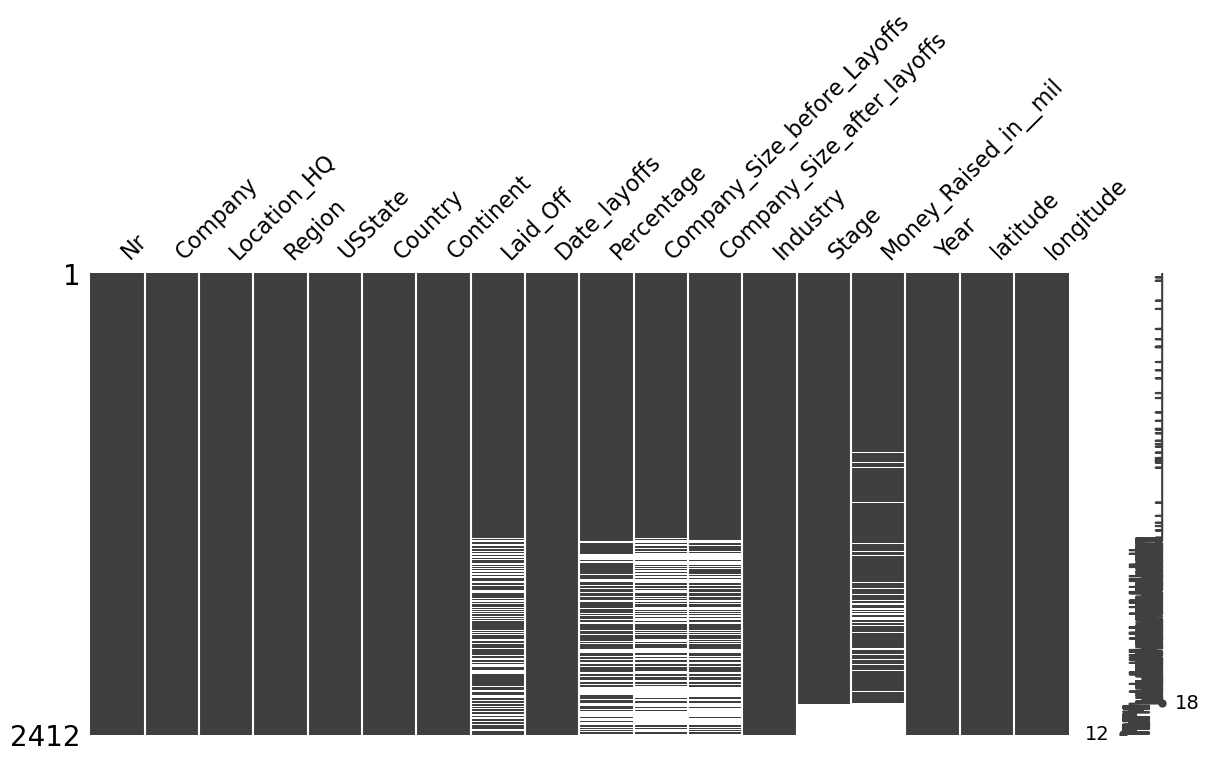

In [136]:
import missingno as msno

msno.matrix(df, figsize=(14,6))
plt.show()

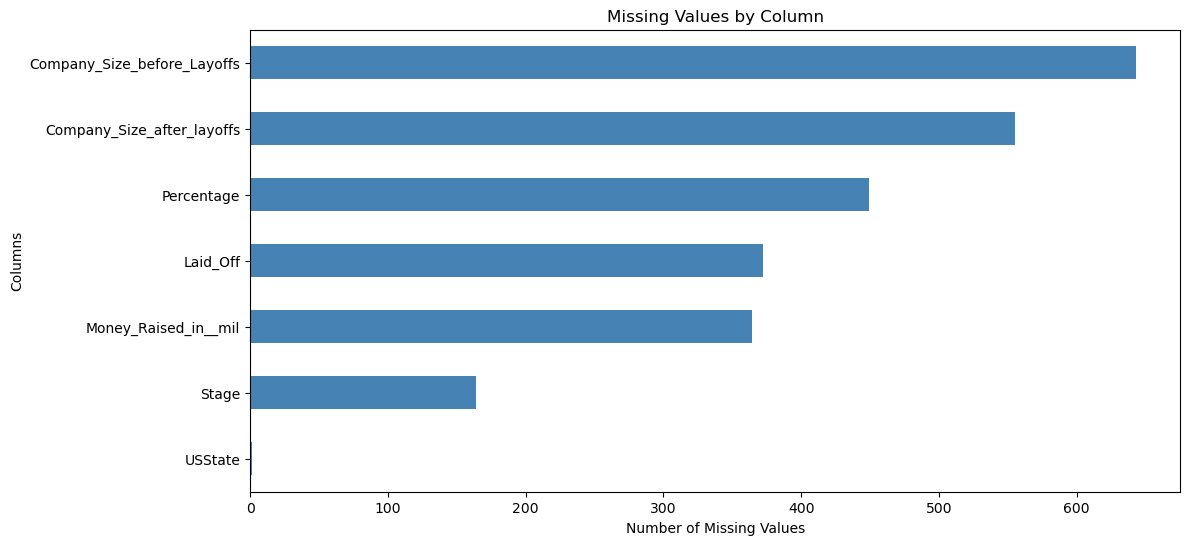

In [137]:
missing = df.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(12,6))
missing.sort_values().plot(kind='barh', color='steelblue')

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")

plt.show()

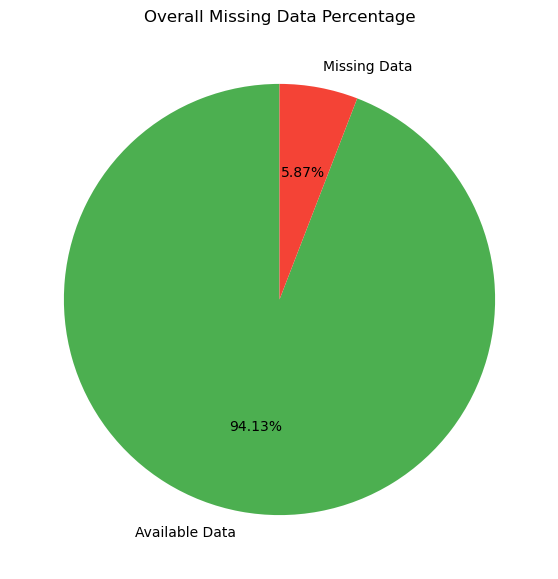

In [138]:
total_missing = df.isnull().sum().sum()
total_values = df.size

labels = ['Available Data', 'Missing Data']
sizes = [total_values-total_missing, total_missing]

plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90,
    colors=['#4CAF50','#F44336']
)

plt.title("Overall Missing Data Percentage")

plt.show()

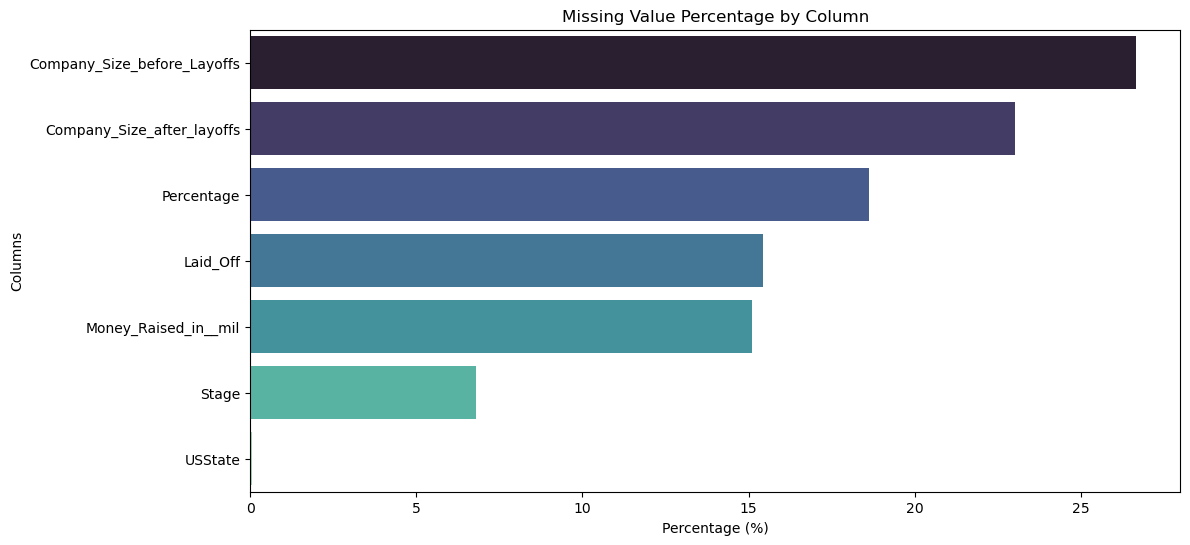

In [140]:
null_percent = (df.isnull().mean()*100).sort_values(ascending=False)

null_percent = null_percent[null_percent>0]

plt.figure(figsize=(12,6))

sns.barplot(
    x=null_percent.values,
    y=null_percent.index,
    palette="mako"
)

plt.xlabel("Percentage (%)")
plt.ylabel("Columns")
plt.title("Missing Value Percentage by Column")

plt.show()

In [141]:
print("="*50)
print("MISSING VALUE REPORT")
print("="*50)

print(f"Total Missing Values : {df.isnull().sum().sum()}")
print(f"Columns with Missing Values : {(df.isnull().sum()>0).sum()}")
print(f"Dataset Completeness : {(1-df.isnull().sum().sum()/df.size)*100:.2f}%")

MISSING VALUE REPORT
Total Missing Values : 2548
Columns with Missing Values : 7
Dataset Completeness : 94.13%


In [142]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


In [143]:
numeric_columns = df.select_dtypes(include=['int64','float64']).columns

numeric_columns

Index(['Nr', 'Laid_Off', 'Percentage', 'Company_Size_before_Layoffs',
       'Company_Size_after_layoffs', 'Money_Raised_in__mil', 'Year',
       'latitude', 'longitude'],
      dtype='object')

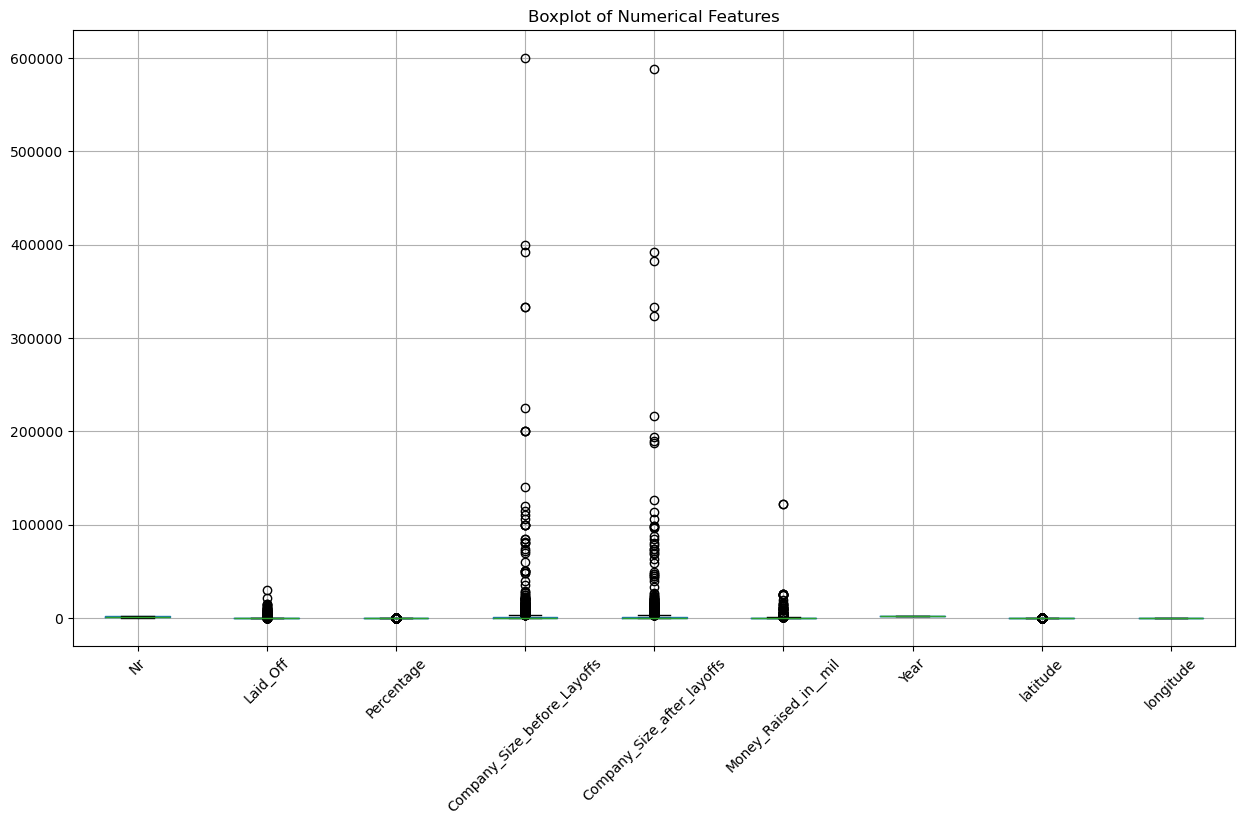

In [144]:
plt.figure(figsize=(15,8))

df[numeric_columns].boxplot(rot=45)

plt.title("Boxplot of Numerical Features")
plt.show()

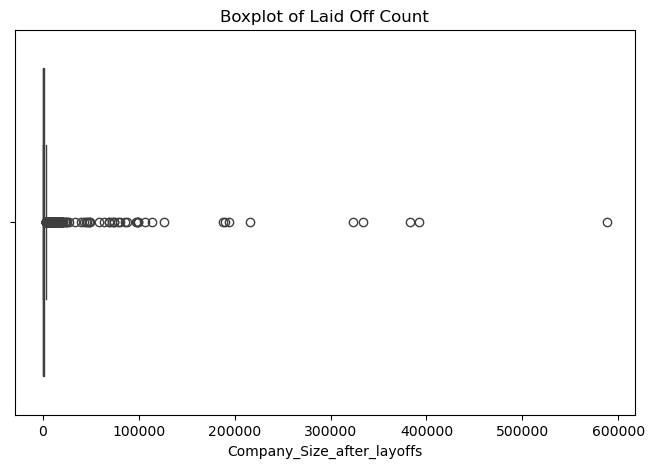

In [145]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Company_Size_after_layoffs"])

plt.title("Boxplot of Laid Off Count")

plt.show()

In [146]:
Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)

IQR = Q3 - Q1

outliers = ((df[numeric_columns] < (Q1 - 1.5*IQR)) |
            (df[numeric_columns] > (Q3 + 1.5*IQR)))

outliers.sum()

Nr                               0
Laid_Off                       258
Percentage                     223
Company_Size_before_Layoffs    252
Company_Size_after_layoffs     263
Money_Raised_in__mil           172
Year                             0
latitude                       342
longitude                        0
dtype: int64

In [148]:
df[outliers.any(axis=1)]

,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude
2,3,Panda Squad,San Francisco,San Francisco Bay Area,California,USA,North America,6.0,2020-03-13,75.0,8.0,2.0,Consumer,Seed,1.0,2020,37.779259,-122.419329
3,4,Help.com,Austin,other,Texas,USA,North America,16.0,2020-03-16,100.0,16.0,0.0,Support,Seed,6.0,2020,30.271129,-97.743700
8,9,Flywheel Sports,New York City,other,New York,USA,North America,784.0,2020-03-20,98.0,800.0,16.0,Fitness,Acquired,120.0,2020,40.712728,-74.006015
9,10,Compass,New York City,other,New York,USA,North America,375.0,2020-03-23,15.0,2500.0,2125.0,Real Estate,Series G,1600.0,2020,40.712728,-74.006015
16,17,Foodsby,Minneapolis,other,Minnesota,USA,North America,87.0,2020-03-24,67.0,130.0,43.0,Food,Series B,20.0,2020,44.977300,-93.265469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2388,2389,Haomo.AI,Beijing,other,non,China,Asia,NaN,2025-11-28,100.0,NaN,0.0,Autonomous Driving Company,NaN,NaN,2025,39.916668,116.383331
2390,2391,TCS,Mumbai,other,Maharashtra,India,Asia,365.0,2025-12-01,NaN,NaN,NaN,IT Services and IT Consulting,NaN,NaN,2025,19.078545,72.878176
2397,2398,Mobileye,Jerusalem,other,non,Israel,Asia,200.0,2025-12-08,4.0,5000.0,4800.0,Autonomous-driving vehicles,NaN,NaN,2025,31.788472,35.218794
2405,2406,Believer Meats,Rehovot,other,non,Israel,Asia,NaN,2025-12-11,100.0,NaN,0.0,Meat Technologies,NaN,NaN,2025,31.891641,34.810296


In [149]:
df_iqr = df[~((df[numeric_columns] < (Q1 - 1.5*IQR)) |
              (df[numeric_columns] > (Q3 + 1.5*IQR))).any(axis=1)]

print(df_iqr.shape)

(1518, 18)


In [156]:
df["Date_layoffs"] = pd.to_datetime(df["Date_layoffs"])

In [157]:
df["Month"] = df["Date_layoffs"].dt.month_name()

In [158]:
df[["Date_layoffs","Month"]].head()

,Date_layoffs,Month
0,2020-03-12,March
1,2020-03-13,March
2,2020-03-13,March
3,2020-03-16,March
4,2020-03-16,March


In [159]:
df["Year"] = df["Date_layoffs"].dt.year

In [160]:
df["Quarter"] = df["Date_layoffs"].dt.quarter

In [161]:
def economic_period(year):
    if year == 2020:
        return "Pandemic"
    elif year == 2021:
        return "Recovery"
    elif year in [2022, 2023]:
        return "Economic Slowdown"
    else:
        return "Stabilization"

df["Economic_Period"] = df["Year"].apply(economic_period)

In [162]:
def company_size(size):

    if size < 100:
        return "Startup"

    elif size < 1000:
        return "Small"

    elif size < 10000:
        return "Medium"

    else:
        return "Large"

df["Company_Size"] = df["Company_Size_before_Layoffs"].apply(company_size)

In [163]:
def layoff_category(x):

    if x < 100:
        return "Low"

    elif x < 1000:
        return "Medium"

    elif x < 5000:
        return "High"

    else:
        return "Mass Layoff"

df["Layoff_Category"] = df["Laid_Off"].apply(layoff_category)

In [164]:
def risk(row):

    if row["Percentage"] >= 80:
        return "Critical"

    elif row["Percentage"] >= 50:
        return "High"

    elif row["Percentage"] >= 20:
        return "Medium"

    else:
        return "Low"

df["Risk_Level"] = df.apply(risk, axis=1)

In [165]:
def funding(money):

    if money < 50:
        return "Low Funding"

    elif money < 500:
        return "Medium Funding"

    else:
        return "High Funding"

df["Funding_Category"] = df["Money_Raised_in__mil"].apply(funding)

In [166]:
df["Layoff_Rate"] = (
    df["Laid_Off"] /
    df["Company_Size_before_Layoffs"]
) * 100

In [167]:
df["Survival_Rate"] = (
    df["Company_Size_after_layoffs"] /
    df["Company_Size_before_Layoffs"]
) * 100

In [168]:
df.head()

,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,...,longitude,Month,Quarter,Economic_Period,Company_Size,Layoff_Category,Risk_Level,Funding_Category,Layoff_Rate,Survival_Rate
0,1,Tamara Mellon,Los Angeles,other,California,USA,North America,20.0,2020-03-12,40.0,...,-118.242766,March,1,Pandemic,Startup,Low,Medium,Medium Funding,40.000000,60.000000
1,2,HopSkipDrive,Los Angeles,other,California,USA,North America,8.0,2020-03-13,10.0,...,-118.242766,March,1,Pandemic,Startup,Low,Low,Low Funding,10.000000,90.000000
2,3,Panda Squad,San Francisco,San Francisco Bay Area,California,USA,North America,6.0,2020-03-13,75.0,...,-122.419329,March,1,Pandemic,Startup,Low,High,Low Funding,75.000000,25.000000
3,4,Help.com,Austin,other,Texas,USA,North America,16.0,2020-03-16,100.0,...,-97.743700,March,1,Pandemic,Startup,Low,Critical,Low Funding,100.000000,0.000000
4,5,Inspirato,Denver,other,Colorado,USA,North America,130.0,2020-03-16,22.0,...,-104.984862,March,1,Pandemic,Small,Medium,Medium,Medium Funding,21.996616,78.003384


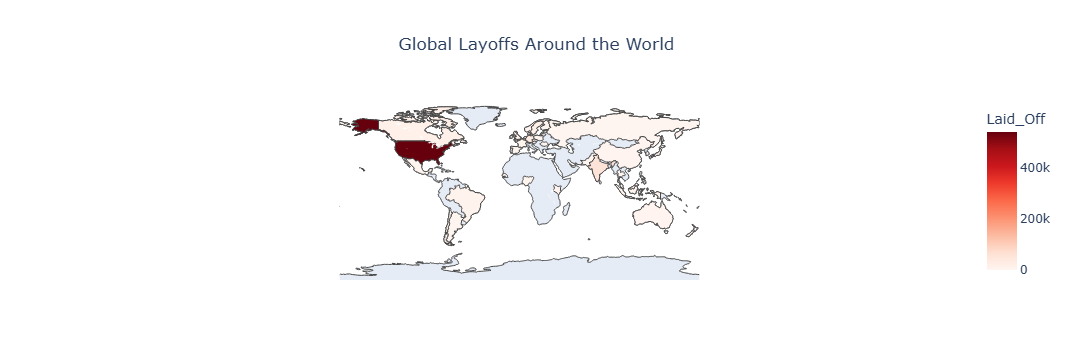

In [169]:
import plotly.express as px

country = (
    df.groupby("Country")["Laid_Off"]
      .sum()
      .reset_index()
)

fig = px.choropleth(
    country,
    locations="Country",
    locationmode="country names",
    color="Laid_Off",
    hover_name="Country",
    color_continuous_scale="Reds",
    title="Global Layoffs Around the World"
)

fig.update_layout(
    title_x=0.5,
    geo=dict(showframe=False, showcoastlines=True)
)

fig.show()

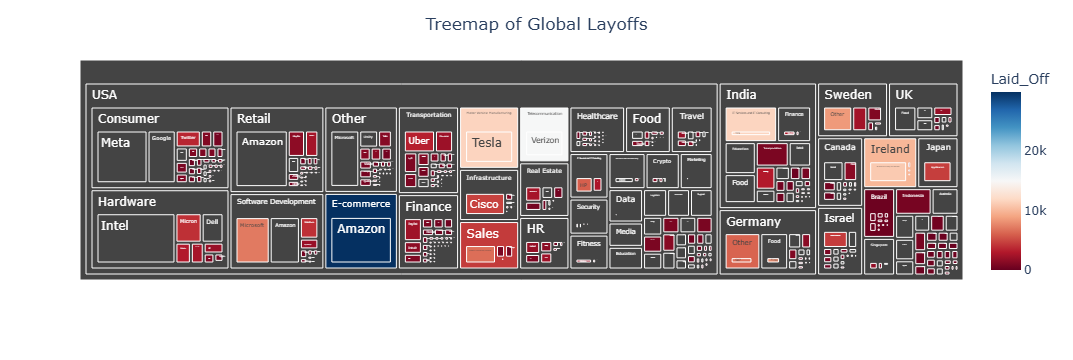

In [170]:
fig = px.treemap(
    df,
    path=["Country", "Industry", "Company"],
    values="Laid_Off",
    color="Laid_Off",
    color_continuous_scale="RdBu"
)

fig.update_layout(
    title="Treemap of Global Layoffs",
    title_x=0.5
)

fig.show()

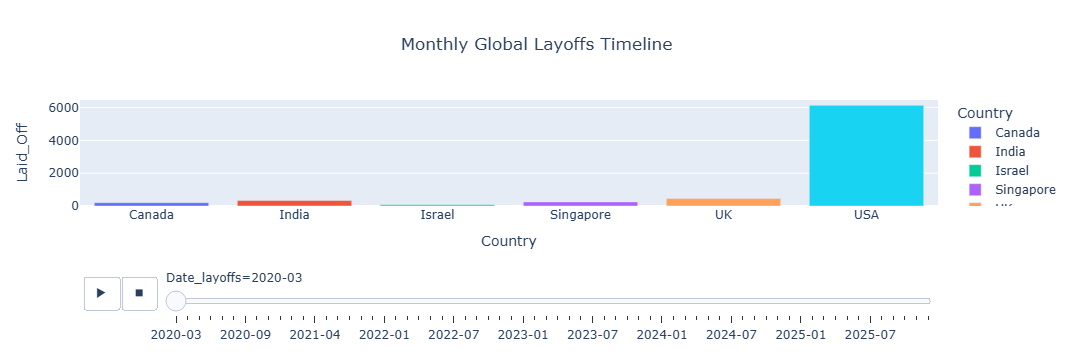

In [171]:
df["Date_layoffs"] = pd.to_datetime(df["Date_layoffs"])

monthly = (
    df.groupby([
        df["Date_layoffs"].dt.to_period("M").astype(str),
        "Country"
    ])["Laid_Off"]
    .sum()
    .reset_index()
)

fig = px.bar(
    monthly,
    x="Country",
    y="Laid_Off",
    animation_frame="Date_layoffs",
    color="Country",
    title="Monthly Global Layoffs Timeline"
)

fig.update_layout(title_x=0.5)

fig.show()

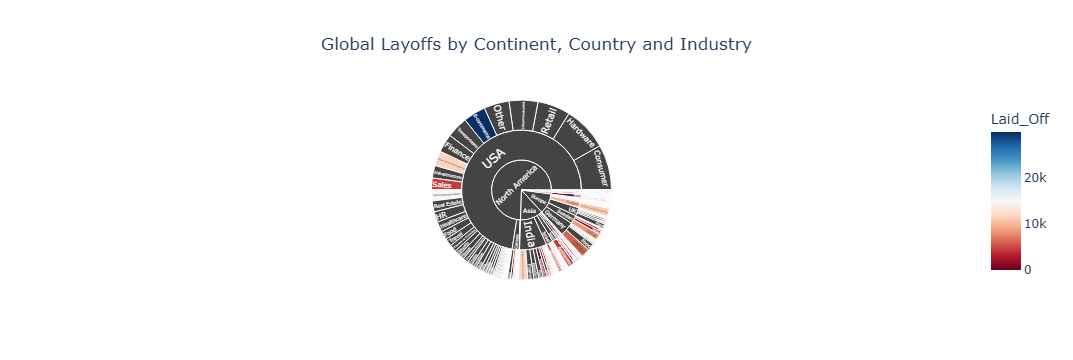

In [172]:
import plotly.express as px

fig = px.sunburst(
    df,
    path=["Continent", "Country", "Industry"],
    values="Laid_Off",
    color="Laid_Off",
    color_continuous_scale="RdBu",
    title="Global Layoffs by Continent, Country and Industry"
)

fig.update_layout(title_x=0.5)

fig.show()

In [175]:
mean_value = df["Laid_Off"].mean()

print("Mean:", round(mean_value,2))

Mean: 366.08


In [176]:
mode_value = df["Laid_Off"].mode()

print("Mode:")
print(mode_value)

Mode:
0    100.0
Name: Laid_Off, dtype: float64


In [177]:
variance = df["Laid_Off"].var()

print("Variance:", round(variance,2))

Variance: 1979576.87


In [178]:
std = df["Laid_Off"].std()

print("Standard Deviation:", round(std,2))

Standard Deviation: 1406.97


In [179]:
skewness = df["Laid_Off"].skew()

print("Skewness:", round(skewness,3))

Skewness: 10.79


In [180]:
kurtosis = df["Laid_Off"].kurt()

print("Kurtosis:", round(kurtosis,3))

Kurtosis: 157.238


In [181]:
from scipy import stats
import numpy as np

data = df["Laid_Off"].dropna()

confidence = 0.95

interval = stats.t.interval(
    confidence,
    len(data)-1,
    loc=np.mean(data),
    scale=stats.sem(data)
)

print("95% Confidence Interval:")
print(interval)

95% Confidence Interval:
(np.float64(304.9918666199657), np.float64(427.17381965454405))


In [184]:
print("="*50)
print("STATISTICAL ANALYSIS REPORT")
print("="*50)

print("Mean:", round(df["Laid_Off"].mean(),2))
print("Median:", df["Laid_Off"].median())
print("Mode:", df["Laid_Off"].mode().values)
print("Variance:", round(df["Laid_Off"].var(),2))
print("Standard Deviation:", round(df["Laid_Off"].std(),2))
print("Skewness:", round(df["Laid_Off"].skew(),3))
print("Kurtosis:", round(df["Laid_Off"].kurt(),3))

STATISTICAL ANALYSIS REPORT
Mean: 366.08
Median: 95.0
Mode: [100.]
Variance: 1979576.87
Standard Deviation: 1406.97
Skewness: 10.79
Kurtosis: 157.238


In [185]:
stats_table = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Mode",
        "Variance",
        "Standard Deviation",
        "Skewness",
        "Kurtosis"
    ],
    "Value": [
        df["Laid_Off"].mean(),
        df["Laid_Off"].median(),
        df["Laid_Off"].mode()[0],
        df["Laid_Off"].var(),
        df["Laid_Off"].std(),
        df["Laid_Off"].skew(),
        df["Laid_Off"].kurt()
    ]
})

stats_table

,Statistic,Value
0,Mean,3.660828e+02
1,Median,9.500000e+01
2,Mode,1.000000e+02
3,Variance,1.979577e+06
4,Standard Deviation,1.406974e+03
5,Skewness,1.079029e+01
6,Kurtosis,1.572382e+02


In [186]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [187]:
ml_df = df.copy()

categorical = [
    "Company",
    "Country",
    "Industry",
    "Stage",
    "Continent"
]

encoder = LabelEncoder()

for col in categorical:
    ml_df[col] = encoder.fit_transform(ml_df[col].astype(str))

In [188]:
features = [
    "Company",
    "Country",
    "Industry",
    "Stage",
    "Money_Raised_in__mil",
    "Company_Size_before_Layoffs",
    "Percentage",
    "Year"
]

X = ml_df[features]

y = ml_df["Laid_Off"]

In [189]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [190]:
lr = LinearRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression")

print("MAE:",mean_absolute_error(y_test,pred_lr))

print("R2:",r2_score(y_test,pred_lr))

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [191]:
ml_df = ml_df.dropna(subset=["Laid_Off"])

In [192]:
features = [
    "Company",
    "Country",
    "Industry",
    "Stage",
    "Money_Raised_in__mil",
    "Company_Size_before_Layoffs",
    "Percentage",
    "Year"
]

X = ml_df[features]
y = ml_df["Laid_Off"]

In [193]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=features
)

In [194]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [195]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [196]:
tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train,y_train)

pred_tree = tree.predict(X_test)

print("Decision Tree")

print("MAE:",mean_absolute_error(y_test,pred_tree))

print("R2:",r2_score(y_test,pred_tree))

Decision Tree
MAE: 184.54509803921567
R2: -0.1507716023787975


In [197]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("Random Forest")

print("MAE:",mean_absolute_error(y_test,pred_rf))

print("R2:",r2_score(y_test,pred_rf))

Random Forest
MAE: 157.06469516108208
R2: 0.373654700732032


In [198]:
importance = pd.DataFrame({

    "Feature":features,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,Company_Size_before_Layoffs,0.494122
0,Company,0.175323
2,Industry,0.108504
6,Percentage,0.107497
1,Country,0.056011
3,Stage,0.042678
4,Money_Raised_in__mil,0.008238
7,Year,0.007627


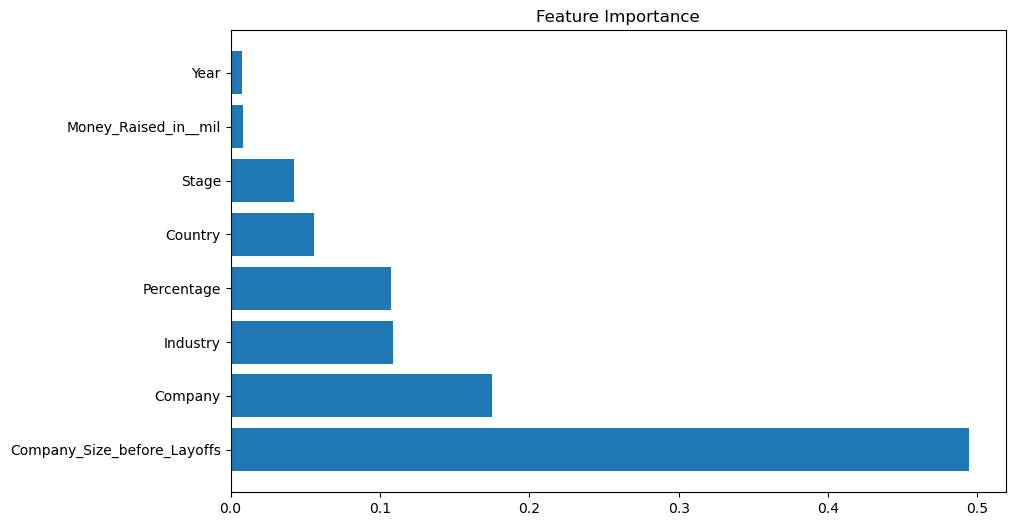

In [199]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.show()

In [200]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)

print("Predicted Layoffs:",prediction[0])

print("Actual Layoffs:",y_test.iloc[0])

Predicted Layoffs: 151.45
Actual Layoffs: 150.0


In [201]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Modellərin nəticələri
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE": [
        mean_absolute_error(y_test, pred_lr),
        mean_absolute_error(y_test, pred_tree),
        mean_absolute_error(y_test, pred_rf)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_lr)),
        np.sqrt(mean_squared_error(y_test, pred_tree)),
        np.sqrt(mean_squared_error(y_test, pred_rf))
    ],

    "R2 Score": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_tree),
        r2_score(y_test, pred_rf)
    ]
})

# Ən yaxşı model (R² yüksək, RMSE aşağı)
results = results.sort_values(by="R2 Score", ascending=False)

print(results)

               Model         MAE         RMSE  R2 Score
0  Linear Regression  316.476666   741.770583  0.376606
2      Random Forest  157.064695   743.524557  0.373655
1      Decision Tree  184.545098  1007.820002 -0.150772


In [202]:
best_model = results.iloc[0]["Model"]

print("="*50)
print("🏆 BEST MODEL")
print("="*50)
print(f"The best model is: {best_model}")

🏆 BEST MODEL
The best model is: Linear Regression


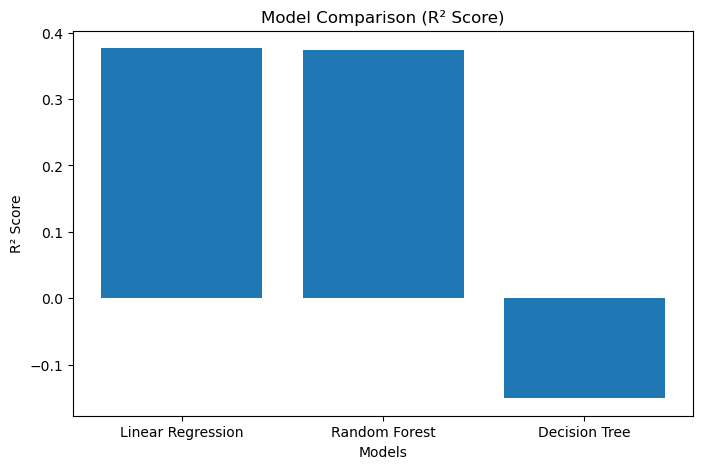

In [203]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2 Score"])

plt.title("Model Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.show()

# AI Insights - Intelligent Data Assistant

In [204]:
import pandas as pd

In [206]:
def ai_agent(question):

    question = question.lower()

    # 1
    if "highest layoffs" in question and "country" in question:

        result = df.groupby("Country")["Laid_Off"].sum().idxmax()

        value = df.groupby("Country")["Laid_Off"].sum().max()

        return f"The country with the highest layoffs is {result} ({int(value)} employees)."

    # 2
    elif "highest layoffs" in question and "company" in question:

        result = df.groupby("Company")["Laid_Off"].sum().idxmax()

        value = df.groupby("Company")["Laid_Off"].sum().max()

        return f"The company with the highest layoffs is {result} ({int(value)} employees)."

    # 3
    elif "top industries" in question:

        return df.groupby("Industry")["Laid_Off"].sum().sort_values(ascending=False).head(10)

    # 4
    elif "more than" in question:

        companies = df[df["Laid_Off"] > 10000][["Company","Country","Laid_Off"]]

        return companies

    # 5
    elif "average layoffs" in question:

        return f"Average layoffs: {df['Laid_Off'].mean():.2f}"

    else:

        return "Sorry, I don't understand this question."
while True:

    question = input("\nAsk AI (type exit to quit): ")

    if question.lower()=="exit":
        break

    print(ai_agent(question))


Ask AI (type exit to quit):  Which country had the highest layoffs?


The country with the highest layoffs is USA (541854 employees).



Ask AI (type exit to quit):  Show companies with more than 10000 layoffs


        Company  Country  Laid_Off
792        Meta      USA   11000.0
987      Google      USA   12000.0
1691      Tesla      USA   14000.0
1902      Intel      USA   15000.0
2191      Intel      USA   22000.0
2275        TCS    India   12000.0
2330  Accenture  Ireland   11000.0
2349     Amazon      USA   30000.0
2368    Verizon      USA   15000.0
2382     Amazon      USA   14000.0



Ask AI (type exit to quit):  Show top industries


Industry
Consumer                         65642.0
Retail                           62190.0
Hardware                         60842.0
Other                            57891.0
Software Development             43634.0
Transportation                   42980.0
Finance                          42857.0
Food                             39006.0
E-commerce                       30874.0
IT Services and IT Consulting    22066.0
Name: Laid_Off, dtype: float64



Ask AI (type exit to quit):  exit


# Automatic Recommendation Engine

In [207]:
# Bu kod ixtisar göstəricilərini təhlil edərək ən kritik vəziyyətdə olan ölkəni, sənayeni və işçilərinin böyük hissəsini itirən riskli şirkətləri müəyyən etmək üçün yazılıb.
# Nəticədə, həm dövlət, həm də özəl sektor üçün hədəfli məşğulluq dəstəyi və maliyyə monitorinqi tələb edən xüsusi strateji tövsiyələr siyahısı formalaşır.
def generate_recommendations(df):

    recommendations = []

    # Recommendation 1
    top_country = df.groupby("Country")["Laid_Off"].sum().idxmax()

    recommendations.append(
        f"Recommendation 1: Focus employment support programs in {top_country}, as it experienced the highest number of layoffs."
    )

    # Recommendation 2
    top_industry = df.groupby("Industry")["Laid_Off"].sum().idxmax()

    recommendations.append(
        f"Recommendation 2: Companies in the {top_industry} industry should strengthen workforce planning and risk management."
    )

    # Recommendation 3
    high_percentage = df[df["Percentage"] >= 80]

    recommendations.append(
        f"Recommendation 3: {len(high_percentage)} companies laid off more than 80% of their workforce. These companies should be monitored for financial instability."
    )

    return recommendations


recommendations = generate_recommendations(df)

for rec in recommendations:
    print(rec)

Recommendation 1: Focus employment support programs in USA, as it experienced the highest number of layoffs.
Recommendation 2: Companies in the Consumer industry should strengthen workforce planning and risk management.
Recommendation 3: 197 companies laid off more than 80% of their workforce. These companies should be monitored for financial instability.


In [208]:
# Bu kod verilənlər bazasındakı ixtisar rəqəmlərini qruplaşdıraraq ən çox təsirlənən ölkə, sənaye və şirkəti dinamik şəkildə müəyyən etmək üçündür.
# Nəticədə, makro və mikro səviyyədə qərarvericilər üçün dataya əsaslanan konkret və ağıllı strateji tövsiyələr hesabatı çap olunur.
def smart_recommendation(df):

    top_country = df.groupby("Country")["Laid_Off"].sum().idxmax()

    top_industry = df.groupby("Industry")["Laid_Off"].sum().idxmax()

    top_company = df.groupby("Company")["Laid_Off"].sum().idxmax()

    print("="*60)
    print("AI STRATEGIC RECOMMENDATIONS")
    print("="*60)

    print(f"""
1. Governments should prioritize employment recovery policies in {top_country},
   where layoffs reached the highest level.

2. Organizations operating in the {top_industry} sector should invest in
   workforce planning, automation strategies, and employee retention.

3. Companies can benchmark against {top_company}, one of the most affected
   organizations, to understand crisis management and restructuring practices.
""")

In [209]:
smart_recommendation(df)

AI STRATEGIC RECOMMENDATIONS

1. Governments should prioritize employment recovery policies in USA,
   where layoffs reached the highest level.

2. Organizations operating in the Consumer sector should invest in
   workforce planning, automation strategies, and employee retention.

3. Companies can benchmark against Amazon, one of the most affected
   organizations, to understand crisis management and restructuring practices.



In [210]:
# Bu kod layihənin ən uğurlu maşın öyrənməsi modelini rəsmi olaraq elan etmək və onun proqnoz gücünə əsaslanaraq strateji qərarlar istehsal etmək üçündür.
# Nəticədə, fərqli biznes tərəfdaşları (şirkətlər, investorlar və HR-lar) üçün dataya əsaslanan fəaliyyət qaydalarını özündə birləşdirən yekun AI tövsiyə hesabatı çap olunur.
best_model = "Random Forest"

print("="*60)
print("AI Recommendation Engine")
print("="*60)

print(f"""
✔ Best prediction model: {best_model}

✔ Companies with high predicted layoff risk should reduce unnecessary hiring.

✔ Countries with increasing layoff trends should introduce workforce support programs.

✔ Industries with continuous layoffs should invest in employee retention.

✔ Investors should carefully monitor companies with high layoff predictions.

✔ HR departments should use predictive analytics for workforce planning.
""")

AI Recommendation Engine

✔ Best prediction model: Random Forest

✔ Companies with high predicted layoff risk should reduce unnecessary hiring.

✔ Countries with increasing layoff trends should introduce workforce support programs.

✔ Industries with continuous layoffs should invest in employee retention.

✔ Investors should carefully monitor companies with high layoff predictions.

✔ HR departments should use predictive analytics for workforce planning.



In [211]:
%pip install reportlab

Note: you may need to restart the kernel to use updated packages.


In [212]:
from reportlab.platypus import SimpleDocTemplate, Paragraph
from reportlab.lib.styles import getSampleStyleSheet

In [213]:
# Bu kod layihə boyu əldə olunan statistik xülasəni, ən yaxşı maşın öyrənməsi modelini və strateji süni intellekt tövsiyələrini avtomatlaşdırılmış şəkildə rəsmiləşdirmək üçündür.
# Nəticədə, bütün tapıntıları və qərarları vahid bir strukturda birləşdirən "Global_Layoffs_Report.pdf" adlı peşəkar hesabat sənədi formalaşır.

from reportlab.platypus import SimpleDocTemplate, Paragraph
from reportlab.lib.styles import getSampleStyleSheet

styles = getSampleStyleSheet()

def generate_pdf():

    doc = SimpleDocTemplate("Global_Layoffs_Report.pdf")

    story = []

    story.append(Paragraph("<b>GLOBAL LAYOFFS 2020-2025 REPORT</b>", styles["Title"]))

    story.append(Paragraph("<br/><b>Dataset Summary</b>", styles["Heading1"]))

    story.append(Paragraph(f"Total Records: {len(df)}", styles["BodyText"]))

    story.append(Paragraph(f"Total Countries: {df['Country'].nunique()}", styles["BodyText"]))

    story.append(Paragraph(f"Total Companies: {df['Company'].nunique()}", styles["BodyText"]))

    story.append(Paragraph(f"Average Layoffs: {df['Laid_Off'].mean():.2f}", styles["BodyText"]))

    story.append(Paragraph("<br/><b>Top Country</b>", styles["Heading1"]))

    top_country = df.groupby("Country")["Laid_Off"].sum().idxmax()

    story.append(Paragraph(top_country, styles["BodyText"]))

    story.append(Paragraph("<br/><b>Top Industry</b>", styles["Heading1"]))

    top_industry = df.groupby("Industry")["Laid_Off"].sum().idxmax()

    story.append(Paragraph(top_industry, styles["BodyText"]))

    story.append(Paragraph("<br/><b>Best Machine Learning Model</b>", styles["Heading1"]))

    story.append(Paragraph(best_model, styles["BodyText"]))

    story.append(Paragraph("<br/><b>Recommendations</b>", styles["Heading1"]))

    story.append(Paragraph(
        "1. Governments should support countries with the highest layoffs.",
        styles["BodyText"]
    ))

    story.append(Paragraph(
        "2. Companies should improve workforce planning.",
        styles["BodyText"]
    ))

    story.append(Paragraph(
        "3. HR departments should use predictive analytics.",
        styles["BodyText"]
    ))

    doc.build(story)

    print("✅ PDF Report Created Successfully!")

In [214]:
generate_pdf()

✅ PDF Report Created Successfully!
